# Supervised control at T = 27: reference data instead of physics

The diagnosis experiment for the continuous-time route's long-horizon failure
(plan and worklog: Notion to-do `3c65d544-b9d9-8170-86a3-de02942a9aa4`,
2026-08-24; runs: HTCondor cluster 5696332, drained 2026-08-25). The identical
network, sample-time distribution, optimiser caps and evaluation as the
physics runs, with the loss swapped for a plain MSE on exactly-integrated
reference states. If the supervised fit succeeds where every physics
configuration failed, the failure is a property of the residual objective,
not of the function class or optimiser.

In [1]:
import json, glob, sys
import numpy as np, pandas as pd
sys.path.insert(0, '../Network_size_study')

summary = pd.read_csv('results/summary_analysis.csv')
summary

,arm,depth,width,n_runs,rel_l2_median,rel_l2_min,rel_l2_max
0,physics causal,4,50,3,1.901207,0.877828,1.990122
1,physics unweighted,4,50,3,0.904441,0.903169,0.905331
2,supervised dens100,4,50,3,0.000432,0.000338,0.000566
3,supervised dens20,4,50,3,0.000339,0.000298,0.000373
4,physics causal,4,64,1,0.420354,0.420354,0.420354
5,physics unweighted,4,64,1,0.903898,0.903898,0.903898
6,supervised dens100,4,64,3,0.000322,0.000280,0.000570
7,supervised dens20,4,64,3,0.000446,0.000399,0.000483
8,physics causal,6,32,1,0.899891,0.899891,0.899891
9,physics unweighted,6,32,1,0.902648,0.902648,0.902648


Every supervised run fits the four-period window to well under 1%:
3.0e-4 to 7.6e-4 for the three moderate architectures at both densities,
2.2e-3 to 4.9e-3 for 10x256 at 20 points per unit time (5.4e5 parameters
against 541 data points), recovering to 3.9e-4 to 5.5e-4 at 100 per unit
time. The physics arms at the same horizon and start: unweighted 0.90 (all
seeds and architectures), causally weighted 0.42 to 2.0. Three to four
orders of magnitude, same networks, same information locations.

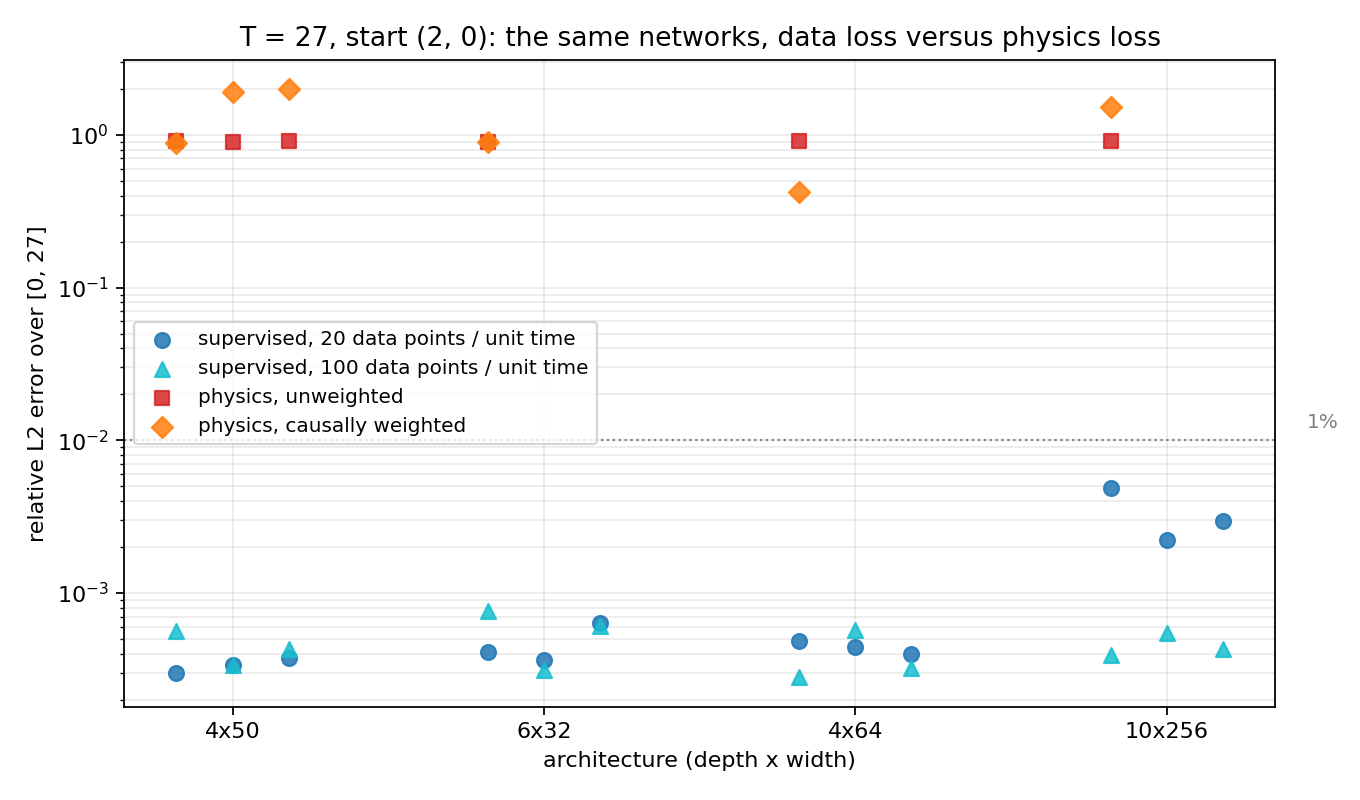

In [2]:
from IPython.display import Image
Image('figures/01_supervised_vs_physics.png')

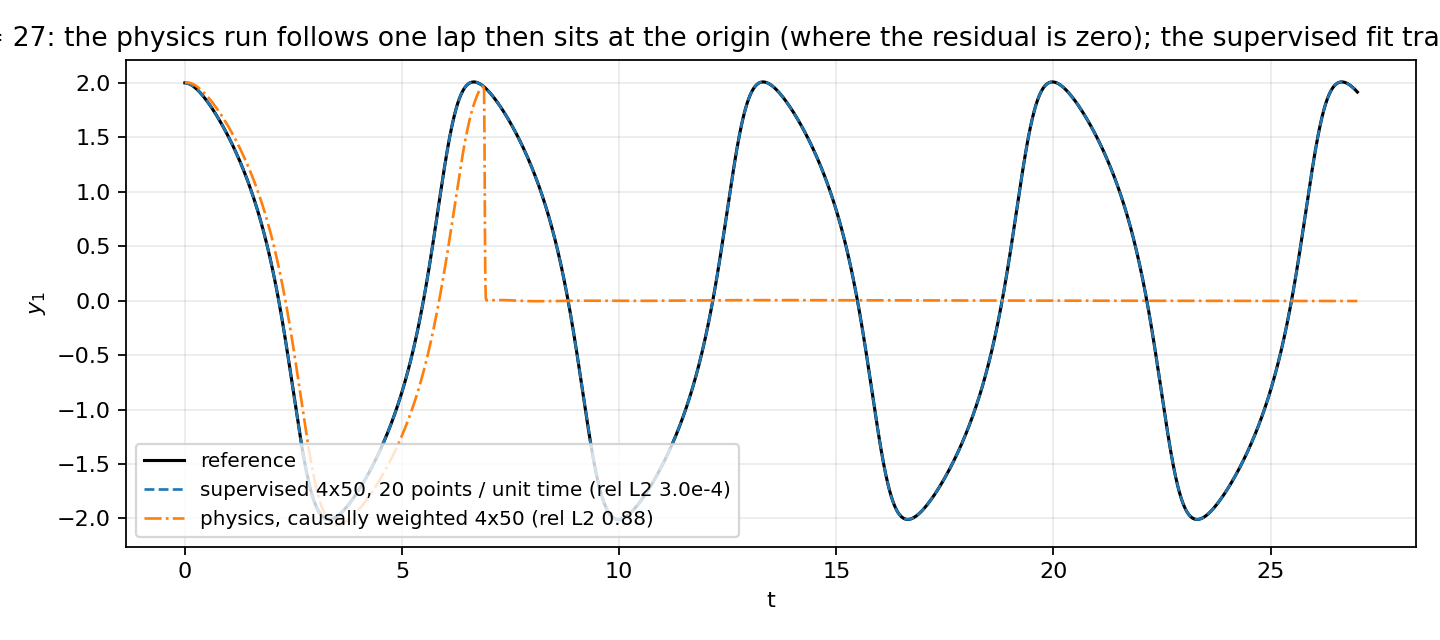

In [3]:
Image('figures/02_trajectory_overlay.png')

## What the failed physics trajectories actually do

The overlay shows the dominant physics failure mode at this horizon, and it
is sharper than a phase drift: the run follows the reference for about one
lap (with growing lag) and then sits at the origin. The origin is the van
der Pol system's unstable equilibrium, and it satisfies the residual
exactly: a constant output has zero time derivative and f(0, 0) = 0. A
trajectory that is anchored for one lap and parked at the fixed point
afterwards has near-zero residual everywhere except a short transition
band, so the physics loss barely objects to it.

In [4]:
z_c = np.load('../Causal_weighting/results/predictions.npz')
z_u = np.load('../Initial_pass/results/predictions.npz')
rows = []
for name, z in (('causal', z_c), ('unweighted', z_u)):
    for s in (0, 1, 2):
        y = z[f'T27_seed{s}_y_net']
        r = np.linalg.norm(y, axis=1)
        rows.append(dict(variant=name, seed=s, median_mod=np.median(r),
                         frac_near_origin=(r < 0.2).mean(), max_mod=r.max()))
pd.DataFrame(rows)

,variant,seed,median_mod,frac_near_origin,max_mod
0,causal,0,0.006403,0.743799,2.875022
1,causal,1,2.819323,0.000000,5.532132
2,causal,2,3.620708,0.000000,4.080769
3,unweighted,0,0.019814,0.729730,1.997727
4,unweighted,1,0.009877,0.728619,1.997917
5,unweighted,2,0.013816,0.729730,1.997787


All three unweighted runs and causal seed 0 spend about 73% of the
window within |y| < 0.2 of the origin (rel L2 about 0.9); causal seeds 1
and 2 instead produce large-amplitude trajectories leaving the limit-cycle
region entirely (|y| up to 5.5, rel L2 1.9 to 2.0). Neither mode is
available to the supervised loss: data at 20 points per unit time forbids
both the parking and the wandering.

## Reading

- The function class and optimiser fit four periods without difficulty;
  the long-horizon failure is a property of the residual objective. In
  particular the objective admits the residual-zero equilibrium branch,
  and the observed failures use it.
- No density ceiling: 20 and 100 points per unit time land in the same
  band (the one exception, 10x256 at density 20, is a parameters-to-data
  ratio effect that the denser set removes).
- Success does not favour size: the largest network is the only one that
  wobbles. This echoes the capacity study's finding that physics-side
  success never correlated with parameter count.
- Caveat carried from the plan: this shows the network could express the
  answer if optimisation of the residual got there; it does not by itself
  say what modification of the physics loss would get there.